In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully!")

KeyboardInterrupt: 

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# # === Dataset Paths ===
BASE_DIR = r"D:\tugas\skripsi\Deam_Dataset"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                         "annotations averaged per song", "song_level")

# --- Load annotation CSVs ---
annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

df1 = pd.read_csv(annot_file_1)
df2 = pd.read_csv(annot_file_2)

# Standardize column names (strip whitespace)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(f"Annotations file 1 shape: {df1.shape}")
print(f"Annotations file 2 shape: {df2.shape}")
print(f"\nFile 1 columns: {list(df1.columns)}")
print(f"File 2 columns: {list(df2.columns)}")
print(f"\nFile 1 sample:")
df1.head()

# # Import library yang dibutuhkan
# import os
# import pandas as pd

# # Sambungkan Google Colab dengan Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # === Dataset Paths ===
# # Menggunakan path Google Drive yang baru
# BASE_DIR = "/content/drive/MyDrive/DEAM_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")

# # --- Load annotation CSVs ---
# annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
# annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

# df1 = pd.read_csv(annot_file_1)
# df2 = pd.read_csv(annot_file_2)

# # Standardize column names (strip whitespace)
# df1.columns = df1.columns.str.strip()
# df2.columns = df2.columns.str.strip()

# print(f"Annotations file 1 shape: {df1.shape}")
# print(f"Annotations file 2 shape: {df2.shape}")
# print(f"\nFile 1 columns: {list(df1.columns)}")
# print(f"File 2 columns: {list(df2.columns)}")
# print(f"\nFile 1 sample:")
# df1.head()

# === Dataset Paths ===
# Using the native Linux path since we are running in WSL
# BASE_DIR = "/home/beingyou/music_emotion_project/DEAM_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")
#
# # --- Load annotation CSVs ---
# annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
# annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")
#
# df1 = pd.read_csv(annot_file_1)
# df2 = pd.read_csv(annot_file_2)
#
# # Standardize column names (strip whitespace)
# df1.columns = df1.columns.str.strip()
# df2.columns = df2.columns.str.strip()
#
# print(f"Annotations file 1 shape: {df1.shape}")
# print(f"Annotations file 2 shape: {df2.shape}")
# print(f"\nFile 1 columns: {list(df1.columns)}")
# print(f"File 2 columns: {list(df2.columns)}")
# print(f"\nFile 1 sample:")
# df1.head()

Annotations file 1 shape: (1744, 5)
Annotations file 2 shape: (58, 13)

File 1 columns: ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']
File 2 columns: ['song_id', 'valence_mean', 'valence_std', 'valence_ max_mean', 'valence_max_std', 'valence_min_mean', 'valence_min_std', 'arousal_mean', 'arousal_std', 'arousal_max_mean', 'arousal_max_std', 'arousal_min_mean', 'arousal_min_std']

File 1 sample:


,song_id,valence_mean,valence_std,arousal_mean,arousal_std
0,2,3.1,0.94,3.0,0.63
1,3,3.5,1.75,3.3,1.62
2,4,5.7,1.42,5.5,1.63
3,5,4.4,2.01,5.3,1.85
4,7,5.8,1.47,6.4,1.69


In [ ]:
# Select common columns: song_id, valence_mean, arousal_mean
# File 1 has: song_id, valence_mean, valence_std, arousal_mean, arousal_std
# File 2 has more columns — we only need the common ones
common_cols = ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']

df1_sel = df1[common_cols].copy()
df2_sel = df2[common_cols].copy()

# Merge both annotation dataframes
annotations = pd.concat([df1_sel, df2_sel], ignore_index=True)
annotations = annotations.drop_duplicates(subset='song_id').reset_index(drop=True)

print(f"Total annotated songs: {len(annotations)}")
print(f"\nMissing values:\n{annotations.isnull().sum()}")
print(f"\n--- Descriptive Statistics ---")
annotations[['valence_mean', 'arousal_mean']].describe()


Total annotated songs: 1802

Missing values:
song_id         0
valence_mean    0
valence_std     0
arousal_mean    0
arousal_std     0
dtype: int64

--- Descriptive Statistics ---


,valence_mean,arousal_mean
count,1802.000000,1802.000000
mean,4.904145,4.814029
std,1.174240,1.282187
min,1.600000,1.600000
25%,4.100000,3.800000
50%,4.900000,4.900000
75%,5.800000,5.800000
max,8.400000,8.100000


Total audio files: 1802
Annotated songs with audio: 1802
Annotated songs without audio: 0

Final dataset size: 1802 songs


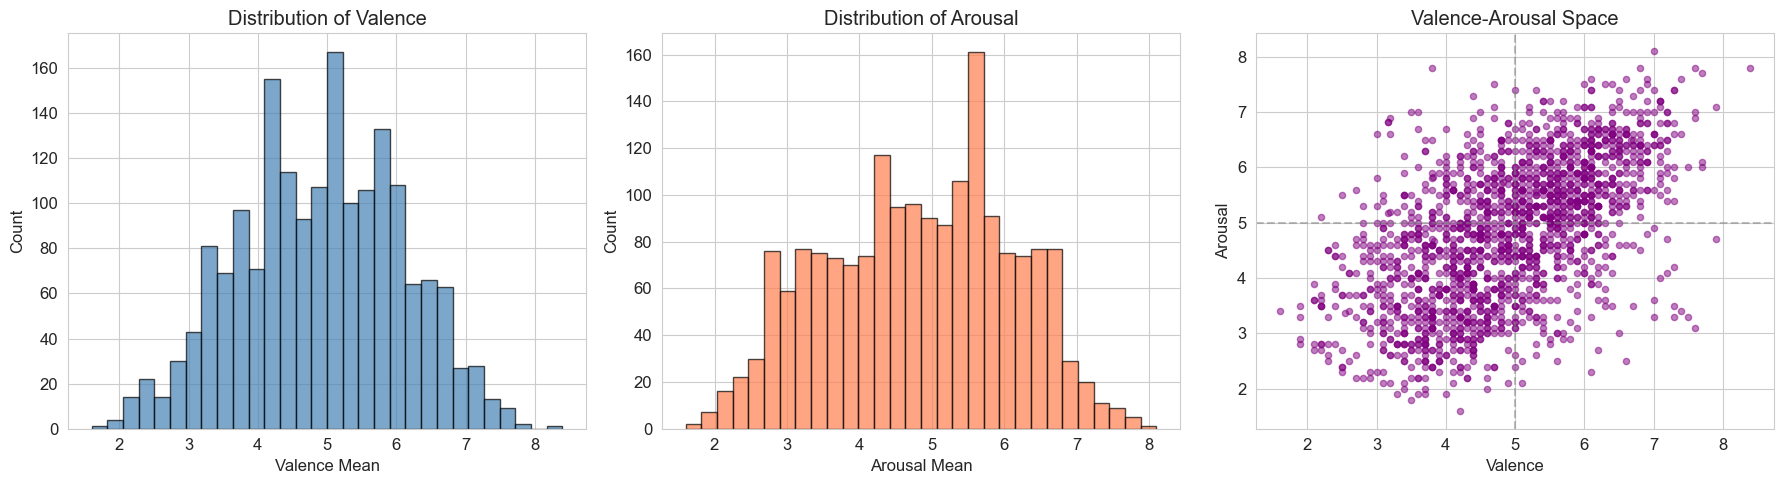

In [ ]:
# Check which annotated songs have audio files available
available_audio = set()
for f in os.listdir(AUDIO_DIR):
    if f.endswith('.mp3'):
        song_id = int(os.path.splitext(f)[0])
        available_audio.add(song_id)

annotations['has_audio'] = annotations['song_id'].isin(available_audio)
print(f"Total audio files: {len(available_audio)}")
print(f"Annotated songs with audio: {annotations['has_audio'].sum()}")
print(f"Annotated songs without audio: {(~annotations['has_audio']).sum()}")

# Keep only songs that have audio
annotations = annotations[annotations['has_audio']].drop(columns='has_audio').reset_index(drop=True)
print(f"\nFinal dataset size: {len(annotations)} songs")

# Plot valence-arousal distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(annotations['valence_mean'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Valence Mean')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Valence')

axes[1].hist(annotations['arousal_mean'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Arousal Mean')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Arousal')

axes[2].scatter(annotations['valence_mean'], annotations['arousal_mean'], alpha=0.5, s=20, c='purple')
axes[2].set_xlabel('Valence')
axes[2].set_ylabel('Arousal')
axes[2].set_title('Valence-Arousal Space')
axes[2].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# === Multi-Scale Mel Spectrogram Extraction ===
# 3 different configurations to capture different time-frequency resolutions:
#   Channel 1: Fine frequency (128 mels, hop=512)  — detailed spectral content
#   Channel 2: Coarse frequency (64 mels, hop=256)  — better time resolution
#   Channel 3: Wide frequency (128 mels, hop=1024) — broader temporal context
SR = 22050
DURATION = 45
N_FFT = 2048

MEL_CONFIGS = [
    {"n_mels": 128, "hop_length": 512,  "label": "fine_freq"},
    {"n_mels": 64,  "hop_length": 256,  "label": "fine_time"},
    {"n_mels": 128, "hop_length": 1024, "label": "wide_context"},
]


def extract_multi_mel(file_path, sr=SR, duration=DURATION, n_fft=N_FFT):
    """
    Extract multiple Mel spectrograms with different configurations.

    Returns:
        dict mapping config label -> log-scaled Mel spectrogram, or None on error
    """
    try:
        y, sr_out = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        result = {}
        for cfg in MEL_CONFIGS:
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=sr_out,
                n_mels=cfg["n_mels"],
                hop_length=cfg["hop_length"],
                n_fft=n_fft
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            result[cfg["label"]] = mel_spec_db
        # --- Chroma feature for key detection (major vs minor) ---
        chroma = librosa.feature.chroma_cqt(y=y, sr=sr_out, hop_length=MEL_CONFIGS[0]["hop_length"])
        chroma_db = librosa.power_to_db(chroma, ref=np.max)
        result["chroma"] = chroma_db

        return result
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


# === Extract Multi-Scale Mel Spectrograms ===
mel_spectrograms_multi = {}
failed_songs = []

print(f"Extracting Multi-Scale Mel Spectrograms for {len(annotations)} songs...")
print(f"Configs: {[c['label'] for c in MEL_CONFIGS]}\n")

for idx, row in tqdm(annotations.iterrows(), total=len(annotations), desc="Extracting"):
    song_id = int(row['song_id'])
    audio_path = os.path.join(AUDIO_DIR, f"{song_id}.mp3")

    result = extract_multi_mel(audio_path)
    if result is not None:
        mel_spectrograms_multi[song_id] = result
    else:
        failed_songs.append(song_id)

# Keep backward-compatible reference for visualization cells
mel_spectrograms = {sid: data["fine_freq"] for sid, data in mel_spectrograms_multi.items()}

print(f"\nSuccessfully extracted: {len(mel_spectrograms_multi)} songs (3 channels each)")
print(f"Failed: {len(failed_songs)} songs")
if failed_songs:
    print(f"Failed song IDs: {failed_songs[:20]}{'...' if len(failed_songs) > 20 else ''}")

Extracting Multi-Scale Mel Spectrograms for 1802 songs...
Configs: ['fine_freq', 'fine_time', 'wide_context']



Extracting: 100%|██████████| 1802/1802 [33:06<00:00,  1.10s/it]


Successfully extracted: 1802 songs (3 channels each)
Failed: 0 songs


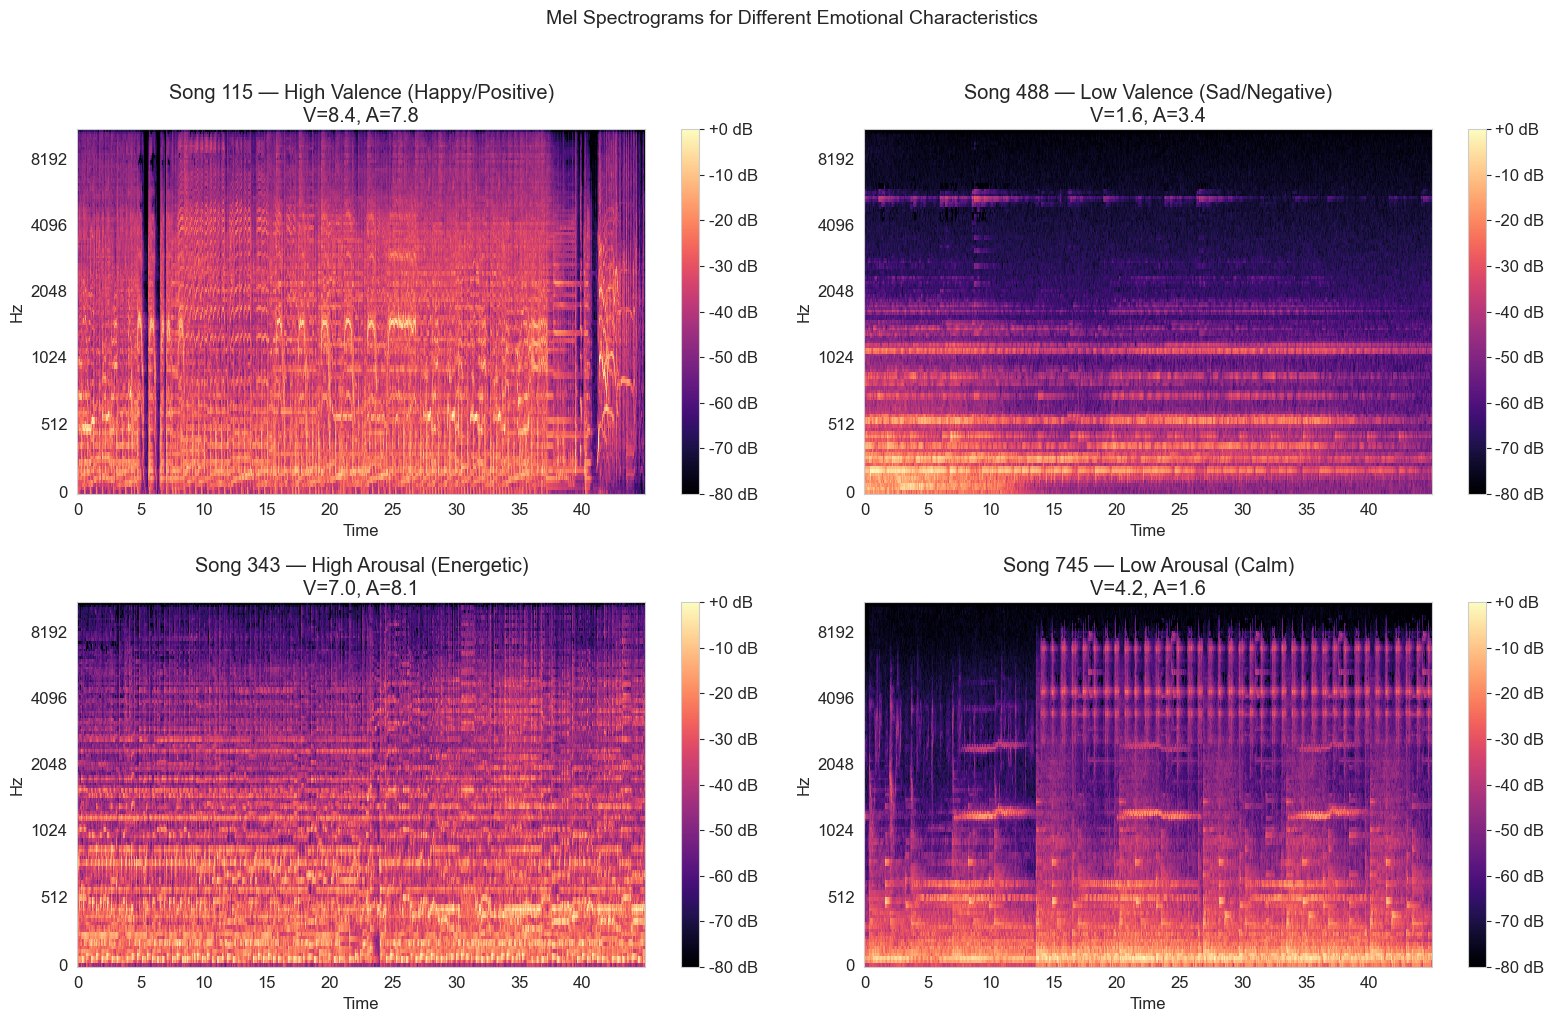

In [ ]:
# Find songs with extreme emotional characteristics
valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()

# Sort by valence to find extremes
high_valence = valid_annot.nlargest(1, 'valence_mean').iloc[0]
low_valence = valid_annot.nsmallest(1, 'valence_mean').iloc[0]
high_arousal = valid_annot.nlargest(1, 'arousal_mean').iloc[0]
low_arousal = valid_annot.nsmallest(1, 'arousal_mean').iloc[0]

samples = [
    (high_valence, "High Valence (Happy/Positive)"),
    (low_valence, "Low Valence (Sad/Negative)"),
    (high_arousal, "High Arousal (Energetic)"),
    (low_arousal, "Low Arousal (Calm)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Use the first mel config's hop_length for display
_display_hop = MEL_CONFIGS[0]["hop_length"]

for i, (song_row, title) in enumerate(samples):
    sid = int(song_row['song_id'])
    mel_spec = mel_spectrograms[sid]

    img = librosa.display.specshow(
        mel_spec, sr=SR, hop_length=_display_hop,
        x_axis='time', y_axis='mel', ax=axes[i]
    )
    axes[i].set_title(f"Song {sid} — {title}\n"
                      f"V={song_row['valence_mean']:.1f}, A={song_row['arousal_mean']:.1f}")
    fig.colorbar(img, ax=axes[i], format="%+2.0f dB")

plt.suptitle("Mel Spectrograms for Different Emotional Characteristics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Dropped 0 ambiguous borderline samples (margin=0.0)

Emotion category distribution:
emotion
Sad/Depressed    686
Happy/Excited    647
Calm/Relaxed     240
Angry/Tense      229
Name: count, dtype: int64

Total samples: 1802


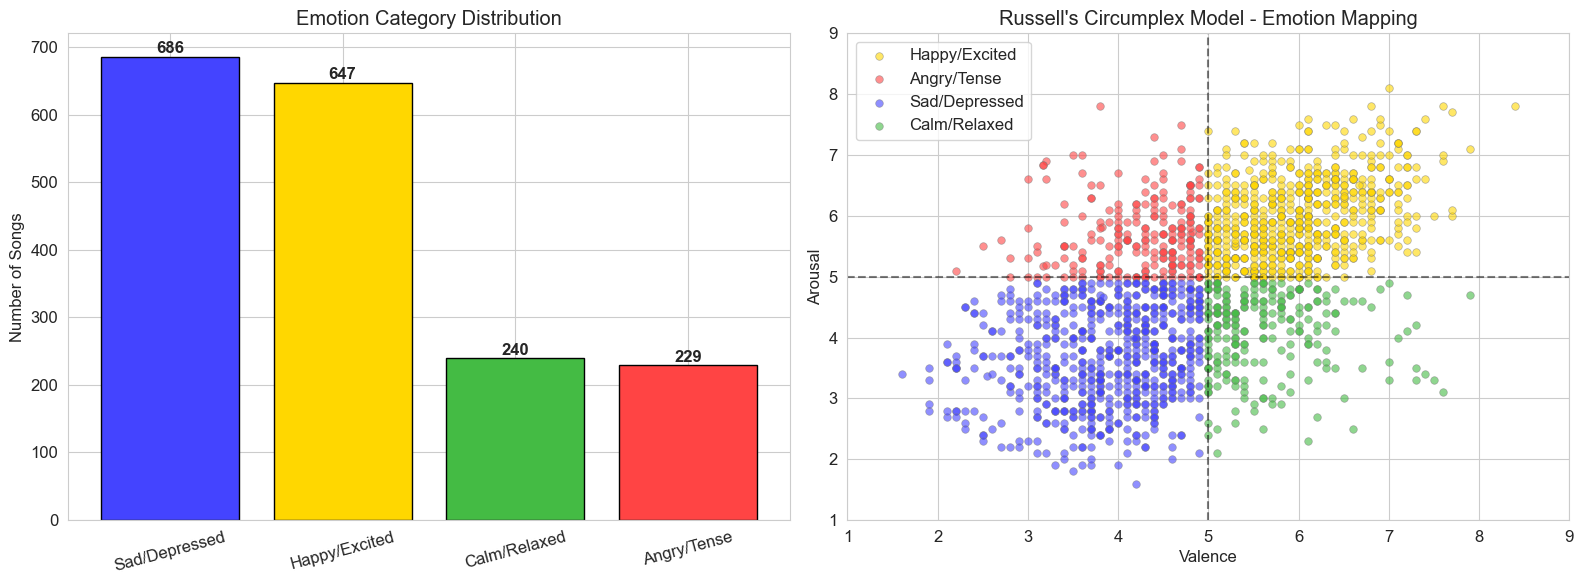

In [ ]:
MARGIN = 0.0  # Retain ALL songs — no borderline filtering to maximize minority class data

def map_emotion(valence, arousal, threshold=5.0, margin=MARGIN):
    """
    Map valence and arousal values to emotion categories using Russell's Circumplex Model.
    Samples within 'margin' of the threshold are dropped as ambiguous.

    Parameters:
        valence: Valence value (1-9 scale)
        arousal: Arousal value (1-9 scale)
        threshold: Midpoint threshold (default 5.0 for DEAM's 1-9 scale)
        margin: Distance from threshold within which samples are considered ambiguous

    Returns:
        Emotion category string, or None if ambiguous
    """
    # Drop borderline samples that are too close to the decision boundary
    if abs(valence - threshold) < margin or abs(arousal - threshold) < margin:
        return None

    if valence >= threshold and arousal >= threshold:
        return "Happy/Excited"
    elif valence < threshold and arousal >= threshold:
        return "Angry/Tense"
    elif valence < threshold and arousal < threshold:
        return "Sad/Depressed"
    else:  # valence >= threshold and arousal < threshold
        return "Calm/Relaxed"


# Apply emotion mapping
valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()
valid_annot['emotion'] = valid_annot.apply(
    lambda row: map_emotion(row['valence_mean'], row['arousal_mean']), axis=1
)

# Filter out ambiguous (borderline) samples
n_before = len(valid_annot)
valid_annot = valid_annot.dropna(subset=['emotion']).reset_index(drop=True)
n_dropped = n_before - len(valid_annot)
print(f"Dropped {n_dropped} ambiguous borderline samples (margin={MARGIN})")

print("\nEmotion category distribution:")
print(valid_annot['emotion'].value_counts())
print(f"\nTotal samples: {len(valid_annot)}")

# Visualize emotion distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
emotion_counts = valid_annot['emotion'].value_counts()
colors = {'Happy/Excited': '#FFD700', 'Angry/Tense': '#FF4444',
          'Sad/Depressed': '#4444FF', 'Calm/Relaxed': '#44BB44'}
bars = axes[0].bar(emotion_counts.index, emotion_counts.values,
                   color=[colors[e] for e in emotion_counts.index], edgecolor='black')
axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Emotion Category Distribution')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Scatter plot colored by emotion
for emotion, color in colors.items():
    subset = valid_annot[valid_annot['emotion'] == emotion]
    axes[1].scatter(subset['valence_mean'], subset['arousal_mean'],
                    c=color, label=emotion, alpha=0.6, s=30, edgecolors='gray', linewidths=0.5)

axes[1].axhline(y=5, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(x=5, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Arousal')
axes[1].set_title("Russell's Circumplex Model - Emotion Mapping")
axes[1].legend(loc='upper left')
axes[1].set_xlim(1, 9)
axes[1].set_ylim(1, 9)

plt.tight_layout()
plt.show()


In [ ]:
def extract_feature_vector(mel_spec_db):
    """
    Extract a fixed-length feature vector from a Mel spectrogram by computing
    summary statistics across the time axis for each Mel frequency band.

    Parameters:
        mel_spec_db: Log-scaled Mel spectrogram (n_mels x time_frames)

    Returns:
        Feature vector of shape (n_mels * 4,) containing mean, std, min, max per band
    """
    mel_mean = np.mean(mel_spec_db, axis=1)
    mel_std = np.std(mel_spec_db, axis=1)
    mel_min = np.min(mel_spec_db, axis=1)
    mel_max = np.max(mel_spec_db, axis=1)

    return np.concatenate([mel_mean, mel_std, mel_min, mel_max])


# Build feature matrix X and label array y
feature_list = []
label_list = []
song_ids_list = []
valence_list = []
arousal_list = []

for idx, row in valid_annot.iterrows():
    song_id = int(row['song_id'])
    if song_id in mel_spectrograms:
        mel_spec = mel_spectrograms[song_id]
        features = extract_feature_vector(mel_spec)
        feature_list.append(features)
        label_list.append(row['emotion'])
        song_ids_list.append(song_id)
        valence_list.append(row['valence_mean'])
        arousal_list.append(row['arousal_mean'])

X = np.array(feature_list)
y = np.array(label_list)
song_ids_arr = np.array(song_ids_list)
valence_arr = np.array(valence_list)
arousal_arr = np.array(arousal_list)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

n_mels_used = MEL_CONFIGS[0]["n_mels"]
print(f"Feature matrix shape: {X.shape}")
print(f"Label array shape: {y.shape}")
print(f"Feature vector size per track: {X.shape[1]} "
      f"({n_mels_used} Mel bands × 4 statistics)")
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nClass distribution:")
for cls, count in zip(*np.unique(y, return_counts=True)):
    print(f"  {cls}: {count} ({count/len(y)*100:.1f}%)")

Feature matrix shape: (1802, 512)
Label array shape: (1802,)
Feature vector size per track: 512 (128 Mel bands × 4 statistics)

Label encoding: {np.str_('Angry/Tense'): np.int64(0), np.str_('Calm/Relaxed'): np.int64(1), np.str_('Happy/Excited'): np.int64(2), np.str_('Sad/Depressed'): np.int64(3)}

Class distribution:
  Angry/Tense: 229 (12.7%)
  Calm/Relaxed: 240 (13.3%)
  Happy/Excited: 647 (35.9%)
  Sad/Depressed: 686 (38.1%)


In [ ]:
# ============================================================
# Compact CNN Setup — reproducible training on spectrogram crops
# ============================================================
import math
import random
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) detected: {len(gpus)}")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — training will use CPU")

print(f"TensorFlow version: {tf.__version__}")


No GPU detected — training will use CPU
TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# Prepare fixed multi-crop CNN data + auxiliary valence/arousal targets
# WITH AUDIO AUGMENTATION for minority class balancing
# ============================================================
CROP_DURATION_SEC = 12.0
TRAIN_CROPS_PER_SONG = 3
EVAL_CROPS_PER_SONG = 5
TARGET_FREQ = 96
TARGET_TIME = 160
MIN_DB = -80.0
AXIS_THRESHOLD = 5.0
INPUT_SHAPE = (TARGET_FREQ, TARGET_TIME, len(MEL_CONFIGS) + 1)  # +1 for chroma channel

# --- Augmentation parameters ---
MAX_TIME_MASK_WIDTH = 20    # max frames to mask in time
MAX_FREQ_MASK_WIDTH = 12    # max frequency bins to mask
NOISE_STD = 0.02            # std dev of Gaussian noise
MAX_SHIFT_FRAMES = 15       # max frames to shift in time
AUGMENT_PROB = 0.5           # probability of applying each augmentation type

song_meta = valid_annot.set_index('song_id')[['valence_mean', 'arousal_mean']]


def temporal_crop(mel_spec_db, crop_frames, position_ratio):
    """Extract a time crop while preserving the original Mel resolution."""
    n_frames = mel_spec_db.shape[1]
    if n_frames <= crop_frames:
        pad_width = crop_frames - n_frames
        return np.pad(
            mel_spec_db,
            ((0, 0), (0, pad_width)),
            mode='constant',
            constant_values=mel_spec_db.min()
        )

    start = int(round(position_ratio * (n_frames - crop_frames)))
    end = start + crop_frames
    return mel_spec_db[:, start:end]


def resize_and_scale_mel(mel_spec_db, target_freq=TARGET_FREQ, target_time=TARGET_TIME, min_db=MIN_DB):
    """Resize a crop and map dB values into [0, 1] for stable CNN training."""
    mel_clipped = np.clip(mel_spec_db, min_db, 0.0).astype(np.float32)
    mel_scaled = (mel_clipped - min_db) / abs(min_db)
    mel_scaled = tf.image.resize(
        mel_scaled[..., np.newaxis],
        [target_freq, target_time],
        method='bilinear'
    ).numpy().squeeze(-1)
    return np.clip(mel_scaled, 0.0, 1.0).astype(np.float16)


def get_axis_targets(song_id):
    row = song_meta.loc[int(song_id)]
    valence_high = 1.0 if row['valence_mean'] >= AXIS_THRESHOLD else 0.0
    arousal_high = 1.0 if row['arousal_mean'] >= AXIS_THRESHOLD else 0.0
    return valence_high, arousal_high


# ============================================================
# Augmentation functions for spectrogram crops
# ============================================================

def augment_time_mask(crop, rng):
    """Apply SpecAugment-style time masking to a multi-channel crop."""
    crop = crop.copy()
    _, time_steps, n_channels = crop.shape
    mask_width = rng.integers(1, MAX_TIME_MASK_WIDTH + 1)
    mask_start = rng.integers(0, max(1, time_steps - mask_width))
    crop[:, mask_start:mask_start + mask_width, :] = 0.0
    return crop


def augment_freq_mask(crop, rng):
    """Apply SpecAugment-style frequency masking to a multi-channel crop."""
    crop = crop.copy()
    freq_bins, _, n_channels = crop.shape
    mask_width = rng.integers(1, MAX_FREQ_MASK_WIDTH + 1)
    mask_start = rng.integers(0, max(1, freq_bins - mask_width))
    crop[mask_start:mask_start + mask_width, :, :] = 0.0
    return crop


def augment_gaussian_noise(crop, rng):
    """Add small Gaussian noise to the spectrogram values."""
    crop = crop.copy().astype(np.float32)
    noise = rng.normal(0.0, NOISE_STD, size=crop.shape).astype(np.float32)
    crop = np.clip(crop + noise, 0.0, 1.0)
    return crop.astype(np.float16)


def augment_time_shift(crop, rng):
    """Randomly shift the spectrogram along the time axis with wrapping."""
    crop = crop.copy()
    _, time_steps, _ = crop.shape
    shift = rng.integers(-MAX_SHIFT_FRAMES, MAX_SHIFT_FRAMES + 1)
    if shift != 0:
        crop = np.roll(crop, shift, axis=1)
    return crop


def augment_spectrogram_crop(crop, seed=None):
    """
    Apply a random combination of augmentation techniques to a single
    spectrogram crop of shape (TARGET_FREQ, TARGET_TIME, num_channels).
    Each augmentation type is applied with probability AUGMENT_PROB.
    """
    rng = np.random.default_rng(seed)

    # Apply each augmentation with AUGMENT_PROB probability
    if rng.random() < AUGMENT_PROB:
        crop = augment_time_mask(crop, rng)

    if rng.random() < AUGMENT_PROB:
        crop = augment_freq_mask(crop, rng)

    if rng.random() < AUGMENT_PROB:
        crop = augment_gaussian_noise(crop, rng)

    if rng.random() < AUGMENT_PROB:
        crop = augment_time_shift(crop, rng)

    return crop


def compute_augmentation_multiplier(class_counts, target_class_idx):
    """
    Compute how many EXTRA augmented crop-sets to generate for a minority class
    to approximately match the largest class count.
    Returns 0 for majority classes (no augmentation needed).
    """
    max_count = max(class_counts.values())
    current_count = class_counts[target_class_idx]
    if current_count >= max_count:
        return 0
    # How many times to multiply (round up) minus 1 for the originals
    multiplier = max(0, round(max_count / current_count) - 1)
    return multiplier


def build_segment_dataset(song_ids, song_labels, num_crops, augment_minority=False):
    """
    Create deterministic crops per song for stable training and song-level averaging.
    
    If augment_minority=True, minority classes (those with fewer songs than the
    largest class) will receive additional augmented crops to balance the dataset.
    """
    crop_ratios = [0.5] if num_crops == 1 else np.linspace(0.0, 1.0, num_crops)
    X_segments = []
    y_emotion = []
    y_valence = []
    y_arousal = []
    crop_song_ids = []

    # Compute class counts for augmentation multiplier
    aug_multipliers = {}
    if augment_minority:
        class_counts = defaultdict(int)
        for label in song_labels:
            class_counts[int(label)] += 1
        for cls_idx in class_counts:
            aug_multipliers[cls_idx] = compute_augmentation_multiplier(class_counts, cls_idx)
        print(f"  Augmentation multipliers per class: {dict(aug_multipliers)}")
        print(f"  Class counts: {dict(class_counts)}")

    aug_seed_counter = SEED * 1000  # deterministic seeds for augmentation

    for song_id, label in zip(song_ids, song_labels):
        valence_target, arousal_target = get_axis_targets(song_id)
        mel_bundle = mel_spectrograms_multi[int(song_id)]
        label_int = int(label)

        for ratio in crop_ratios:
            channels = []
            for cfg in MEL_CONFIGS:
                mel = mel_bundle[cfg["label"]]
                crop_frames = max(16, int(round(CROP_DURATION_SEC * SR / cfg["hop_length"])))
                mel_crop = temporal_crop(mel, crop_frames=crop_frames, position_ratio=ratio)
                channels.append(resize_and_scale_mel(mel_crop))

            # Add chroma channel (resized from 12 bins to TARGET_FREQ)
            chroma = mel_bundle["chroma"]
            chroma_crop_frames = max(16, int(round(CROP_DURATION_SEC * SR / MEL_CONFIGS[0]["hop_length"])))
            chroma_crop = temporal_crop(chroma, crop_frames=chroma_crop_frames, position_ratio=ratio)
            channels.append(resize_and_scale_mel(chroma_crop))

            original_crop = np.stack(channels, axis=-1)
            X_segments.append(original_crop)
            y_emotion.append(label_int)
            y_valence.append(np.float32(valence_target))
            y_arousal.append(np.float32(arousal_target))
            crop_song_ids.append(int(song_id))

            # Generate augmented copies for minority classes
            if augment_minority and label_int in aug_multipliers:
                n_aug = aug_multipliers[label_int]
                for aug_i in range(n_aug):
                    aug_seed_counter += 1
                    aug_crop = augment_spectrogram_crop(original_crop, seed=aug_seed_counter)
                    X_segments.append(aug_crop)
                    y_emotion.append(label_int)
                    y_valence.append(np.float32(valence_target))
                    y_arousal.append(np.float32(arousal_target))
                    crop_song_ids.append(int(song_id))

    return (
        np.asarray(X_segments, dtype=np.float16),
        np.asarray(y_emotion, dtype=np.int32),
        np.asarray(y_valence, dtype=np.float32),
        np.asarray(y_arousal, dtype=np.float32),
        np.asarray(crop_song_ids, dtype=np.int32),
    )


song_ids_all = valid_annot['song_id'].to_numpy()
song_labels_all = valid_annot['emotion'].to_numpy()

le_cnn = LabelEncoder()
y_song_encoded = le_cnn.fit_transform(song_labels_all)
NUM_CLASSES = len(le_cnn.classes_)
CLASS_NAMES = list(le_cnn.classes_)

song_ids_tv, song_ids_test, y_tv_songs, y_test_songs = train_test_split(
    song_ids_all,
    y_song_encoded,
    test_size=0.15,
    random_state=SEED,
    stratify=y_song_encoded,
)

song_ids_train, song_ids_val, y_train_songs, y_val_songs = train_test_split(
    song_ids_tv,
    y_tv_songs,
    test_size=0.176,
    random_state=SEED,
    stratify=y_tv_songs,
)

# Build training data WITH augmentation for minority classes
print("Building training data with minority-class augmentation...")
X_train_crops, y_train_emotion, y_train_valence, y_train_arousal, train_crop_song_ids = build_segment_dataset(
    song_ids_train, y_train_songs, TRAIN_CROPS_PER_SONG, augment_minority=True
)

# Build val/test data WITHOUT augmentation
X_val_crops, y_val_emotion, y_val_valence, y_val_arousal, val_crop_song_ids = build_segment_dataset(
    song_ids_val, y_val_songs, EVAL_CROPS_PER_SONG, augment_minority=False
)
X_test_crops, y_test_emotion, y_test_valence, y_test_arousal, test_crop_song_ids = build_segment_dataset(
    song_ids_test, y_test_songs, EVAL_CROPS_PER_SONG, augment_minority=False
)

print(
    f"Song split sizes -- Train: {len(song_ids_train)}, "
    f"Val: {len(song_ids_val)}, Test: {len(song_ids_test)}"
)
print(
    f"Crop tensor shapes -- Train: {X_train_crops.shape}, "
    f"Val: {X_val_crops.shape}, Test: {X_test_crops.shape}"
)
print(f"Classes: {CLASS_NAMES}")

print("\nSong distribution per split:")
for idx, cls in enumerate(CLASS_NAMES):
    train_count = int((y_train_songs == idx).sum())
    val_count = int((y_val_songs == idx).sum())
    test_count = int((y_test_songs == idx).sum())
    print(f"  {cls}: train={train_count}, val={val_count}, test={test_count}")

# Show crop distribution (including augmented)
print("\nCrop distribution in training data (with augmentation):")
for idx, cls in enumerate(CLASS_NAMES):
    crop_count = int((y_train_emotion == idx).sum())
    print(f"  {cls}: {crop_count} crops")


In [ ]:
# ============================================================
# Multi-task compact CNN: quadrant classification + valence/arousal heads
# ============================================================
BATCH_SIZE = 32
EPOCHS = 45
BEST_MODEL_PATH = "best_cnn_compact.keras"
AUTOTUNE = tf.data.AUTOTUNE
AXIS_BLEND = 0.35  # Increased from 0.15 to give valence/arousal heads more influence
MINORITY_CLASS_NAMES = ("Angry/Tense", "Calm/Relaxed")

emotion_class_counts = np.bincount(y_train_emotion, minlength=NUM_CLASSES)
# NOTE: class weights removed — balanced sampler already handles class imbalance.
# Using both simultaneously caused double compensation and gradient instability.
minority_class_ids = [CLASS_NAMES.index(name) for name in MINORITY_CLASS_NAMES if name in CLASS_NAMES]
MINORITY_CLASS_IDS = tf.constant(minority_class_ids, dtype=tf.int32)


def random_time_shift(image, max_shift=8):
    shift = tf.random.uniform([], -max_shift, max_shift + 1, dtype=tf.int32)
    return tf.roll(image, shift=shift, axis=1)


def random_freq_mask(image, max_mask=10):
    n_freq = tf.shape(image)[0]
    mask_len = tf.random.uniform([], 1, max_mask + 1, dtype=tf.int32)
    max_start = tf.maximum(1, n_freq - mask_len + 1)
    start = tf.random.uniform([], 0, max_start, dtype=tf.int32)
    mask = tf.concat(
        [
            tf.ones([start, tf.shape(image)[1], tf.shape(image)[2]], dtype=image.dtype),
            tf.zeros([mask_len, tf.shape(image)[1], tf.shape(image)[2]], dtype=image.dtype),
            tf.ones([n_freq - start - mask_len, tf.shape(image)[1], tf.shape(image)[2]], dtype=image.dtype),
        ],
        axis=0,
    )
    return image * mask


def random_time_mask(image, max_mask=18):
    n_time = tf.shape(image)[1]
    mask_len = tf.random.uniform([], 1, max_mask + 1, dtype=tf.int32)
    max_start = tf.maximum(1, n_time - mask_len + 1)
    start = tf.random.uniform([], 0, max_start, dtype=tf.int32)
    mask = tf.concat(
        [
            tf.ones([tf.shape(image)[0], start, tf.shape(image)[2]], dtype=image.dtype),
            tf.zeros([tf.shape(image)[0], mask_len, tf.shape(image)[2]], dtype=image.dtype),
            tf.ones([tf.shape(image)[0], n_time - start - mask_len, tf.shape(image)[2]], dtype=image.dtype),
        ],
        axis=1,
    )
    return image * mask


def random_gain(image, min_scale=0.90, max_scale=1.10):
    scale = tf.random.uniform([], min_scale, max_scale)
    return image * scale


def augment_spectrogram(image, targets):
    image = tf.cast(image, tf.float32)
    emotion = tf.cast(targets['emotion'], tf.int32)
    is_minority = tf.reduce_any(tf.equal(emotion, MINORITY_CLASS_IDS))
    minority_boost = tf.cast(is_minority, tf.float32)

    # Gentler minority boost (balanced sampler already ensures representation)
    shift_prob = 0.30 + 0.10 * minority_boost
    noise_prob = 0.20 + 0.08 * minority_boost
    freq_mask_prob = 0.20 + 0.08 * minority_boost
    time_mask_prob = 0.20 + 0.08 * minority_boost
    gain_prob = 0.10 + 0.08 * minority_boost

    image = tf.cond(tf.random.uniform([]) < shift_prob, lambda: random_time_shift(image), lambda: image)
    image = tf.cond(
        tf.random.uniform([]) < noise_prob,
        lambda: image + tf.random.normal(tf.shape(image), stddev=0.01),
        lambda: image,
    )
    image = tf.cond(tf.random.uniform([]) < freq_mask_prob, lambda: random_freq_mask(image), lambda: image)
    image = tf.cond(tf.random.uniform([]) < time_mask_prob, lambda: random_time_mask(image), lambda: image)
    image = tf.cond(tf.random.uniform([]) < gain_prob, lambda: random_gain(image), lambda: image)

    extra_minority_mask = tf.logical_and(is_minority, tf.random.uniform([]) < 0.25)
    image = tf.cond(extra_minority_mask, lambda: random_time_mask(image, max_mask=24), lambda: image)

    return tf.clip_by_value(image, 0.0, 1.0), targets


def build_targets(emotion, valence, arousal):
    return {
        'emotion': emotion,
        'valence': valence,
        'arousal': arousal,
    }


def make_eval_dataset(X, y_emotion, y_valence, y_arousal, batch_size):
    targets = build_targets(y_emotion, y_valence, y_arousal)
    return (
        tf.data.Dataset.from_tensor_slices((X, targets))
        .map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )


def make_balanced_train_dataset(X, y_emotion, y_valence, y_arousal, batch_size):
    class_datasets = []
    crop_counts = {}

    for class_idx in range(NUM_CLASSES):
        mask = y_emotion == class_idx
        crop_counts[CLASS_NAMES[class_idx]] = int(mask.sum())
        targets = build_targets(y_emotion[mask], y_valence[mask], y_arousal[mask])
        ds = tf.data.Dataset.from_tensor_slices((X[mask], targets))
        ds = ds.shuffle(max(int(mask.sum()) * 4, 64), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.repeat().map(augment_spectrogram, num_parallel_calls=AUTOTUNE)
        class_datasets.append(ds)

    sampled = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1.0 / NUM_CLASSES] * NUM_CLASSES,
        seed=SEED,
    )
    sampled = sampled.batch(batch_size).prefetch(AUTOTUNE)
    target_crops_per_class = max(crop_counts.values()) if crop_counts else 0
    return sampled, crop_counts, target_crops_per_class


# NOTE: weighted_emotion_loss removed — using standard sparse_categorical_crossentropy
# since the balanced sampler already handles class imbalance.


def conv_bn_act(x, filters, kernel_size=3, strides=1, weight_decay=1e-4):
    x = layers.SeparableConv2D(
        filters,
        kernel_size,
        strides=strides,
        padding='same',
        use_bias=False,
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    return x


def residual_block(x, filters, pool=False, dropout_rate=0.0):
    shortcut = x
    x = conv_bn_act(x, filters)
    x = conv_bn_act(x, filters)

    if pool:
        x = layers.AveragePooling2D(pool_size=2)(x)
        shortcut = layers.AveragePooling2D(pool_size=2)(shortcut)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('swish')(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    return x


def build_multitask_spec_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(24, 5, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = residual_block(x, 24, pool=False, dropout_rate=0.05)
    x = residual_block(x, 48, pool=True, dropout_rate=0.08)
    x = residual_block(x, 96, pool=True, dropout_rate=0.10)
    x = residual_block(x, 144, pool=True, dropout_rate=0.12)
    x = residual_block(x, 192, pool=True, dropout_rate=0.15)

    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([gap, gmp])
    x = layers.Dense(160, use_bias=False, kernel_regularizer=regularizers.l2(8e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.25)(x)

    emotion_output = layers.Dense(num_classes, activation='softmax', name='emotion')(x)
    valence_output = layers.Dense(1, activation='sigmoid', name='valence')(x)
    arousal_output = layers.Dense(1, activation='sigmoid', name='arousal')(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=[emotion_output, valence_output, arousal_output],
        name='multitask_spec_cnn',
    )


def unpack_outputs(outputs):
    if isinstance(outputs, dict):
        emotion_probs = outputs['emotion']
        valence_probs = outputs['valence']
        arousal_probs = outputs['arousal']
    else:
        emotion_probs, valence_probs, arousal_probs = outputs

    return (
        np.asarray(emotion_probs, dtype=np.float32),
        np.asarray(valence_probs, dtype=np.float32).reshape(-1),
        np.asarray(arousal_probs, dtype=np.float32).reshape(-1),
    )


def blend_quadrant_probs(emotion_probs, valence_probs, arousal_probs, axis_blend=AXIS_BLEND):
    axis_probs = np.stack(
        [
            (1.0 - valence_probs) * arousal_probs,          # Angry/Tense
            valence_probs * (1.0 - arousal_probs),          # Calm/Relaxed
            valence_probs * arousal_probs,                  # Happy/Excited
            (1.0 - valence_probs) * (1.0 - arousal_probs),  # Sad/Depressed
        ],
        axis=1,
    )
    combined = (1.0 - axis_blend) * emotion_probs + axis_blend * axis_probs
    combined /= np.clip(combined.sum(axis=1, keepdims=True), 1e-8, None)
    return combined


# Post-processing: override to Calm/Relaxed when auxiliary heads are confident
CALM_VALENCE_THRESHOLD = 0.55
CALM_AROUSAL_THRESHOLD = 0.45

def apply_calm_relaxed_override(blended_probs, valence_probs, arousal_probs,
                                valence_threshold=CALM_VALENCE_THRESHOLD,
                                arousal_threshold=CALM_AROUSAL_THRESHOLD):
    """Override prediction to Calm/Relaxed when auxiliary heads are confident
    about high valence + low arousal, bypassing emotion head's Sad bias."""
    calm_class_idx = CLASS_NAMES.index('Calm/Relaxed')
    overridden = blended_probs.copy()
    for i in range(len(blended_probs)):
        if valence_probs[i] > valence_threshold and arousal_probs[i] < arousal_threshold:
            overridden[i] = np.zeros(len(CLASS_NAMES))
            overridden[i, calm_class_idx] = 1.0
    return overridden


class SongLevelMetrics(callbacks.Callback):
    """Aggregate crop predictions back to song level using class + axis heads."""

    def __init__(self, x_val, y_val_emotion, song_ids, batch_size):
        super().__init__()
        self.x_val = x_val
        self.y_val_emotion = y_val_emotion
        self.song_ids = song_ids
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        outputs = self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0)
        emotion_probs, valence_probs, arousal_probs = unpack_outputs(outputs)
        crop_probs = blend_quadrant_probs(emotion_probs, valence_probs, arousal_probs)
        crop_probs = apply_calm_relaxed_override(crop_probs, valence_probs, arousal_probs)

        grouped_probs = defaultdict(list)
        grouped_labels = {}
        for song_id, probs, label in zip(self.song_ids, crop_probs, self.y_val_emotion):
            grouped_probs[int(song_id)].append(probs)
            grouped_labels[int(song_id)] = int(label)

        y_true_song = []
        y_pred_song = []
        for song_id in grouped_probs:
            mean_prob = np.mean(grouped_probs[song_id], axis=0)
            y_true_song.append(grouped_labels[song_id])
            y_pred_song.append(int(np.argmax(mean_prob)))

        song_acc = accuracy_score(y_true_song, y_pred_song)
        weighted_f1 = f1_score(y_true_song, y_pred_song, average='weighted', zero_division=0)
        macro_f1 = f1_score(y_true_song, y_pred_song, average='macro', zero_division=0)
        logs['val_song_accuracy'] = song_acc
        logs['val_weighted_f1'] = weighted_f1
        logs['val_macro_f1'] = macro_f1
        print(
            f" - val_song_accuracy: {song_acc:.4f}"
            f" - val_weighted_f1: {weighted_f1:.4f}"
            f" - val_macro_f1: {macro_f1:.4f}",
            end='',
        )


train_ds, train_crop_counts, target_crops_per_class = make_balanced_train_dataset(
    X_train_crops, y_train_emotion, y_train_valence, y_train_arousal, BATCH_SIZE
)
val_ds = make_eval_dataset(X_val_crops, y_val_emotion, y_val_valence, y_val_arousal, BATCH_SIZE)
test_ds = make_eval_dataset(X_test_crops, y_test_emotion, y_test_valence, y_test_arousal, BATCH_SIZE)

balanced_epoch_crops = target_crops_per_class * NUM_CLASSES
steps_per_epoch = max(1, math.ceil(balanced_epoch_crops / BATCH_SIZE))
song_metrics_cb = SongLevelMetrics(
    X_val_crops,
    y_val_emotion,
    val_crop_song_ids,
    batch_size=BATCH_SIZE,
)

tf.keras.backend.clear_session()
model = build_multitask_spec_cnn(INPUT_SHAPE, NUM_CLASSES)
# LR warmup to prevent early gradient collapse
WARMUP_EPOCHS = 3
BASE_LR = 2.5e-4

def warmup_schedule(epoch, lr):
    if epoch < WARMUP_EPOCHS:
        return BASE_LR * (epoch + 1) / WARMUP_EPOCHS
    return lr

warmup_cb = callbacks.LearningRateScheduler(warmup_schedule)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=BASE_LR, weight_decay=1e-4),
    loss={
        'emotion': 'sparse_categorical_crossentropy',
        'valence': 'binary_crossentropy',
        'arousal': 'binary_crossentropy',
    },
    loss_weights={
        'emotion': 1.0,
        'valence': 0.30,
        'arousal': 0.30,
    },
    metrics={
        'emotion': ['accuracy'],
        'valence': ['accuracy'],
        'arousal': ['accuracy'],
    },
)

print("Original crop counts in the training split:")
for cls, count in train_crop_counts.items():
    print(f"  {cls}: {count} crops")

print(f"\nBalanced sampler target per class per epoch: {target_crops_per_class} crops")
print(f"Steps per epoch: {steps_per_epoch}")
model.summary()


Original crop counts in the training split:
  Angry/Tense: 480 crops
  Calm/Relaxed: 504 crops
  Happy/Excited: 1359 crops
  Sad/Depressed: 1440 crops

Balanced sampler target per class per epoch: 1440 crops
Steps per epoch: 180


Model: "multitask_spec_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 160,   │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 80,    │      2,400 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 80,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 48, 80,    │        792 │ activation[0][0]  │
│ (SeparableConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 80,    │         96 │ separable_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 48, 80,    │        792 │ activation_1[0][… │
│ (SeparableConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 80,    │         96 │ separable_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 80,    │          0 │ activation_2[0][… │
│                     │ 24)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 48, 80,    │          0 │ add[0][0]         │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 48, 80,    │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 48, 80,    │      1,368 │ spatial_dropout2… │
│ (SeparableConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 80,    │        192 │ separable_conv2d… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 48, 80,    │      2,736 │ activation_4[0][

 Total params: 243,790 (952.30 KB)

 Trainable params: 240,446 (939.24 KB)

 Non-trainable params: 3,344 (13.06 KB)

In [ ]:
sample_images, sample_targets = next(iter(train_ds.take(1)))
print(f"Sample batch shape: {sample_images.shape}")
print(f"Emotion labels: {sample_targets['emotion'][:10].numpy()}")
print(f"Valence targets: {sample_targets['valence'][:10].numpy().reshape(-1)}")
print(f"Arousal targets: {sample_targets['arousal'][:10].numpy().reshape(-1)}")


Sample batch shape: (32, 96, 160, 4)
Emotion labels: [1 0 0 3 1 3 2 1 0 1]
Valence targets: [1. 0. 0. 0. 1. 0. 1. 1. 0. 1.]
Arousal targets: [0. 1. 1. 0. 0. 0. 1. 0. 1. 0.]


In [ ]:
# ============================================================
# Train multi-task compact CNN
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor='val_macro_f1',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_macro_f1',
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)
ckpt = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_macro_f1',
    mode='max',
    save_best_only=True,
    verbose=1,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[song_metrics_cb, warmup_cb, reduce_lr, early_stop, ckpt],
    verbose=1,
)

model = tf.keras.models.load_model(BEST_MODEL_PATH)

print(f"\nBest crop-level val_emotion_accuracy: {max(history.history['val_emotion_accuracy']):.4f}")
print(f"Best song-level val_accuracy: {max(history.history['val_song_accuracy']):.4f}")
print(f"Best song-level val_weighted_f1: {max(history.history['val_weighted_f1']):.4f}")
print(f"Best song-level val_macro_f1: {max(history.history['val_macro_f1']):.4f}")
print(f"Total epochs run: {len(history.history['loss'])}")


Epoch 1/45
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - arousal_accuracy: 0.5309 - arousal_loss: 0.7460 - emotion_accuracy: 0.3310 - emotion_loss: 1.4872 - loss: 2.0549 - valence_accuracy: 0.4927 - valence_loss: 0.7794 - val_song_accuracy: 0.3593 - val_weighted_f1: 0.1899 - val_macro_f1: 0.1322
Epoch 1: val_macro_f1 improved from None to 0.13215, saving model to best_cnn_compact.keras

Epoch 1: finished saving model to best_cnn_compact.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - arousal_accuracy: 0.5470 - arousal_loss: 0.7347 - emotion_accuracy: 0.3660 - emotion_loss: 1.4123 - loss: 1.9684 - valence_accuracy: 0.5172 - valence_loss: 0.7521 - val_arousal_accuracy: 0.4852 - val_arousal_loss: 0.7541 - val_emotion_accuracy: 0.3593 - val_emotion_loss: 1.3743 - val_loss: 1.9234 - val_valence_accuracy: 0.5074 - val_valence_loss: 0.6970 - val_song_accuracy: 0.3593 - val_weighted_f1: 0.1899 - val_macro_f1: 0.1322 - learning_rate: 8.3333e-05
Epoch 2/45
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/ste

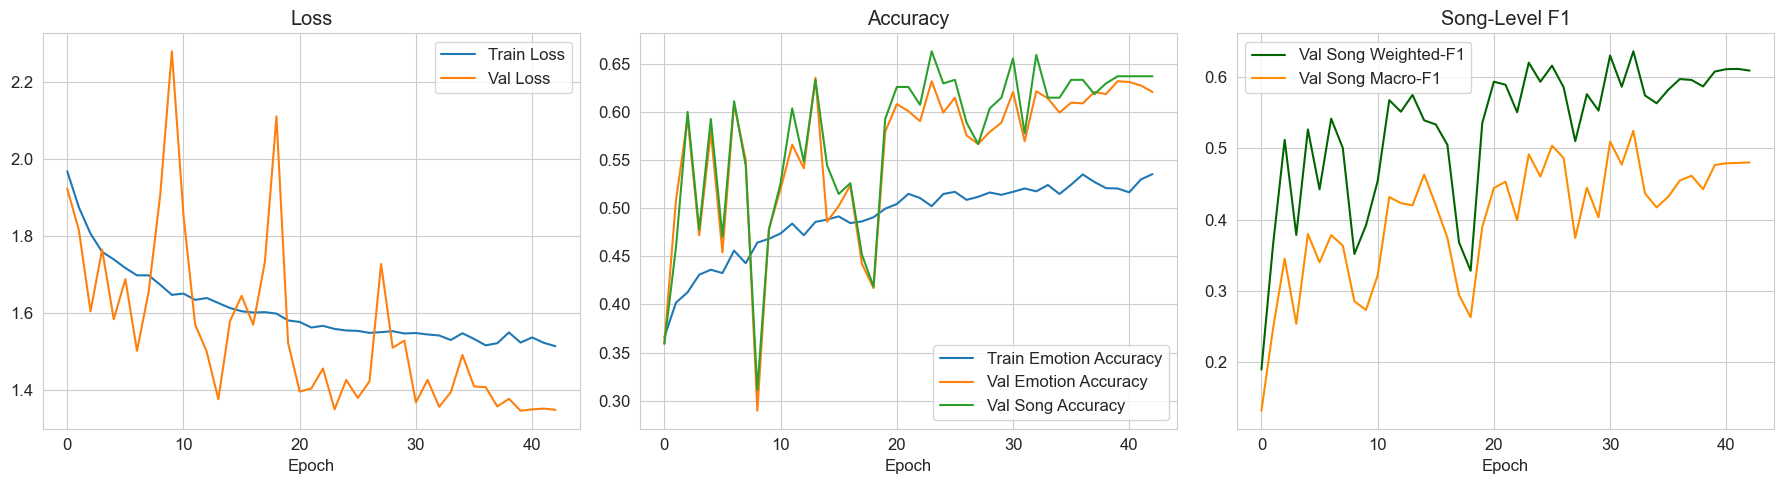

In [ ]:
# ============================================================
# Training history
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history.history['emotion_accuracy'], label='Train Emotion Accuracy')
axes[1].plot(history.history['val_emotion_accuracy'], label='Val Emotion Accuracy')
axes[1].plot(history.history['val_song_accuracy'], label='Val Song Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)
axes[1].legend()

axes[2].plot(history.history['val_weighted_f1'], label='Val Song Weighted-F1', color='darkgreen')
axes[2].plot(history.history['val_macro_f1'], label='Val Song Macro-F1', color='darkorange')
axes[2].set_title('Song-Level F1')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()


Crop-level Test Loss: 1.3758
Crop-level Emotion Accuracy: 0.6236
Crop-level Valence Accuracy: 0.7299
Crop-level Arousal Accuracy: 0.7956
Song-level Test Accuracy (blended + TTA): 0.6458
Song-level Test Weighted-F1: 0.6136
Song-level Test Macro-F1: 0.4960

Song-level Classification Report:
               precision    recall  f1-score   support

  Angry/Tense       0.30      0.09      0.13        35
 Calm/Relaxed       0.41      0.33      0.37        36
Happy/Excited       0.65      0.79      0.71        97
Sad/Depressed       0.73      0.81      0.77       103

     accuracy                           0.65       271
    macro avg       0.52      0.50      0.50       271
 weighted avg       0.60      0.65      0.61       271



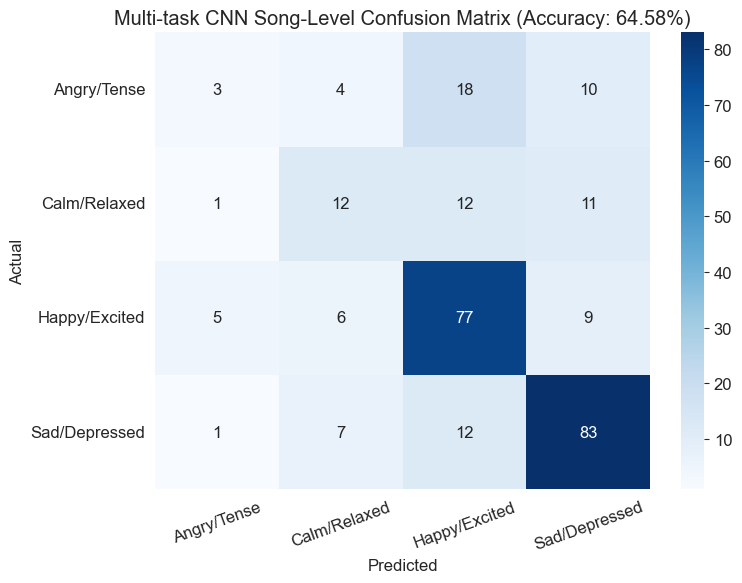


Per-class song-level accuracy:
  Angry/Tense: 8.57% (35 songs)
  Calm/Relaxed: 33.33% (36 songs)
  Happy/Excited: 79.38% (97 songs)
  Sad/Depressed: 80.58% (103 songs)


In [ ]:
# ============================================================
# Evaluate on Test Set — combine class head with valence/arousal heads
# ============================================================
def aggregate_song_predictions(crop_probs, crop_labels, crop_song_ids):
    grouped_probs = defaultdict(list)
    grouped_labels = {}

    for song_id, probs, label in zip(crop_song_ids, crop_probs, crop_labels):
        grouped_probs[int(song_id)].append(probs)
        grouped_labels[int(song_id)] = int(label)

    song_ids = []
    y_true_song = []
    y_pred_song = []
    y_prob_song = []

    for song_id in sorted(grouped_probs):
        mean_prob = np.mean(grouped_probs[song_id], axis=0)
        song_ids.append(song_id)
        y_true_song.append(grouped_labels[song_id])
        y_pred_song.append(int(np.argmax(mean_prob)))
        y_prob_song.append(mean_prob)

    return (
        np.asarray(song_ids, dtype=np.int32),
        np.asarray(y_true_song, dtype=np.int32),
        np.asarray(y_pred_song, dtype=np.int32),
        np.asarray(y_prob_song, dtype=np.float32),
    )


def predict_with_tta(model, X, batch_size):
    variants = [
        X,
        np.roll(X, shift=4, axis=2),
        np.roll(X, shift=-4, axis=2),
    ]

    emotion_list = []
    valence_list = []
    arousal_list = []
    for variant in variants:
        outputs = model.predict(variant, batch_size=batch_size, verbose=0)
        emotion_probs, valence_probs, arousal_probs = unpack_outputs(outputs)
        emotion_list.append(emotion_probs)
        valence_list.append(valence_probs)
        arousal_list.append(arousal_probs)

    return (
        np.mean(emotion_list, axis=0),
        np.mean(valence_list, axis=0),
        np.mean(arousal_list, axis=0),
    )


eval_results = model.evaluate(test_ds, return_dict=True, verbose=0)
emotion_probs, valence_probs, arousal_probs = predict_with_tta(model, X_test_crops, batch_size=BATCH_SIZE)
test_crop_probs = blend_quadrant_probs(emotion_probs, valence_probs, arousal_probs)
test_crop_probs = apply_calm_relaxed_override(test_crop_probs, valence_probs, arousal_probs)

song_ids_eval, y_true_song, y_pred_song, y_prob_song = aggregate_song_predictions(
    test_crop_probs,
    y_test_emotion,
    test_crop_song_ids,
)

song_acc = accuracy_score(y_true_song, y_pred_song)
song_weighted_f1 = f1_score(y_true_song, y_pred_song, average='weighted', zero_division=0)
song_macro_f1 = f1_score(y_true_song, y_pred_song, average='macro', zero_division=0)

print(f"Crop-level Test Loss: {eval_results['loss']:.4f}")
print(f"Crop-level Emotion Accuracy: {eval_results['emotion_accuracy']:.4f}")
print(f"Crop-level Valence Accuracy: {eval_results['valence_accuracy']:.4f}")
print(f"Crop-level Arousal Accuracy: {eval_results['arousal_accuracy']:.4f}")
print(f"Song-level Test Accuracy (blended + TTA): {song_acc:.4f}")
print(f"Song-level Test Weighted-F1: {song_weighted_f1:.4f}")
print(f"Song-level Test Macro-F1: {song_macro_f1:.4f}\n")

target_names = le_cnn.classes_
print("Song-level Classification Report:")
print(classification_report(y_true_song, y_pred_song, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true_song, y_pred_song)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Multi-task CNN Song-Level Confusion Matrix (Accuracy: {song_acc:.2%})')
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nPer-class song-level accuracy:")
for i, cls in enumerate(target_names):
    mask = y_true_song == i
    if mask.sum() > 0:
        acc = (y_pred_song[mask] == i).sum() / mask.sum()
        print(f"  {cls}: {acc:.2%} ({mask.sum()} songs)")
